# Побудова моделі


<h2>Мета</h2>

Ознайомитись з різновидами регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Будувати регресійні моделі кількох видів
* Оцінювати якість моделі візуально
* Оцінювати якість моделі за допомогою числових мір, без використання тестової вибірки
* Виконувати прогнозування відгуку, використовуючи побудовану модель



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>

1. Скачати дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Записати дані у dataframe. В попередній роботі ви визначили ознаки, що можуть бути предикторами для 'CO2 emission'. Побудуйте моделі лінійної регресії для кожного з цих предикторів.
2. Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.
3. Побудуйте кілька поліноміальних моделей другого порядку.
4. Побудуйте візуалізації для оцінки всіх моделей.
5. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.


<a name="task1"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>



Зчитую дані з файлу у датафрейм та імпортую бібліотеки, потрібні для побудови моделей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

path = "data/clean_data.csv"
df = pd.read_csv(path)
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


<p>З попередньої роботи та кореляційного аналізу знаємо, що найкращими кількісними показниками для прогнозування <code>CO2 emission</code> можуть бути:</p>
<ul>
<li><code>Population</code></li>
<li><code>Area</code></li>
</ul>
<p>Розробимо моделі, використовуючи ці ознаки.</p>

In [2]:
df[['Population', 'Area', 'GDP per capita', 'Density', 'CO2 emission']].corr()['CO2 emission'].sort_values(key=lambda x: x.abs(), ascending=False)

CO2 emission      1.000000
Population        0.804091
Area              0.551697
GDP per capita    0.088426
Density          -0.023559
Name: CO2 emission, dtype: float64

Знаходжу коефіцієнти моделі


In [3]:
lm1 = LinearRegression()
X1 = df[['Population']]
Y = df['CO2 emission']
lm1.fit(X1, Y)

print('intercept =', lm1.intercept_)
print('coef =', lm1.coef_)

intercept = -8619.50501753707
coef = [0.00484832]


Отримали кінцеву лінійну модель зі структурою:
$$
Yhat1 = a + b  X
$$

Підставляючи фактичні значення, маємо:

In [4]:
# CO2 emission = -8619.5050 + 0.00484832 * Population

Створюю об’єкт лінійної регресії та навчаю другу модель


In [5]:
lm2 = LinearRegression()
X2 = df[['Area']]
lm2.fit(X2, Y)
lm2

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.23]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3646
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


Знаходжу коефіцієнти моделі


In [6]:
print('intercept =', lm2.intercept_)
print('coef =', lm2.coef_)

intercept = 3646.087523958151
coef = [0.23136652]


Отримали кінцеву лінійну модель зі структурою:
$$
Yhat2 = a + b  X
$$

Підставляючи фактичні значення, маємо:


In [7]:
# CO2 emission = 3646.0875 + 0.23136652 * Area

<a name="task2"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.</p>
</div>

Створюю об’єкт лінійної регресії та навчаю множинну лінійну модель із структурою
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [8]:
lm3 = LinearRegression()
X3 = df[['Population', 'Area']]
lm3.fit(X3, Y)
lm3

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0. ,0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Population','Area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.79e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


Знаходжу коефіцієнти моделі


In [9]:
print('intercept =', lm3.intercept_)
print('coef =', lm3.coef_)

intercept = -57898.205938172
coef = [0.00419112 0.10806919]


Підставляючи фактичні значення, маємо:

In [10]:
# CO2 emission = -57898.2059 + 0.00419112 * Population + 0.10806919 * Area

<a name="task3"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей другого порядку.</p>
</div>

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

Знаходжу коефіцієнти моделі


In [11]:
x1 = df['Population']
y = df['CO2 emission']

f4 = np.polyfit(x1, y, 2)
p4 = np.poly1d(f4)
print(p4)

            2
-3.855e-13 x + 0.005332 x - 1.777e+04


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

Знаходжу коефіцієнти моделі


In [12]:
x2 = df['Area']

f5 = np.polyfit(x2, y, 2)
p5 = np.poly1d(f5)
print(p5)

            2
-1.292e-08 x + 0.3826 x - 4.305e+04


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

Знаходжу коефіцієнти моделі


In [13]:
poly3 = PolynomialFeatures(degree=2, include_bias=False)
X3_poly = poly3.fit_transform(X3)
lm6 = LinearRegression()
lm6.fit(X3_poly, Y)

print('features =', poly3.get_feature_names_out(['Population', 'Area']))
print('intercept =', lm6.intercept_)
print('coef =', lm6.coef_)

features = ['Population' 'Area' 'Population^2' 'Population Area' 'Area^2']
intercept = 55052.78023916745
coef = [-5.75800009e-16 -9.40990043e-17 -1.50841420e-12  1.03506034e-09
 -1.35507959e-09]


<a name="task4"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте візуалізації для оцінки всіх моделей.</p>
</div>

Для простої лінійної регресії чудовим способом візуалізації відповідності моделі є використання графіків регресії. Цей графік покаже комбінацію розсіяних точок даних (діаграма розсіювання, scatterplot) та підігнану лінію лінійної регресії, що проходить через дані.

Таким способом візуалізую перші моделі.


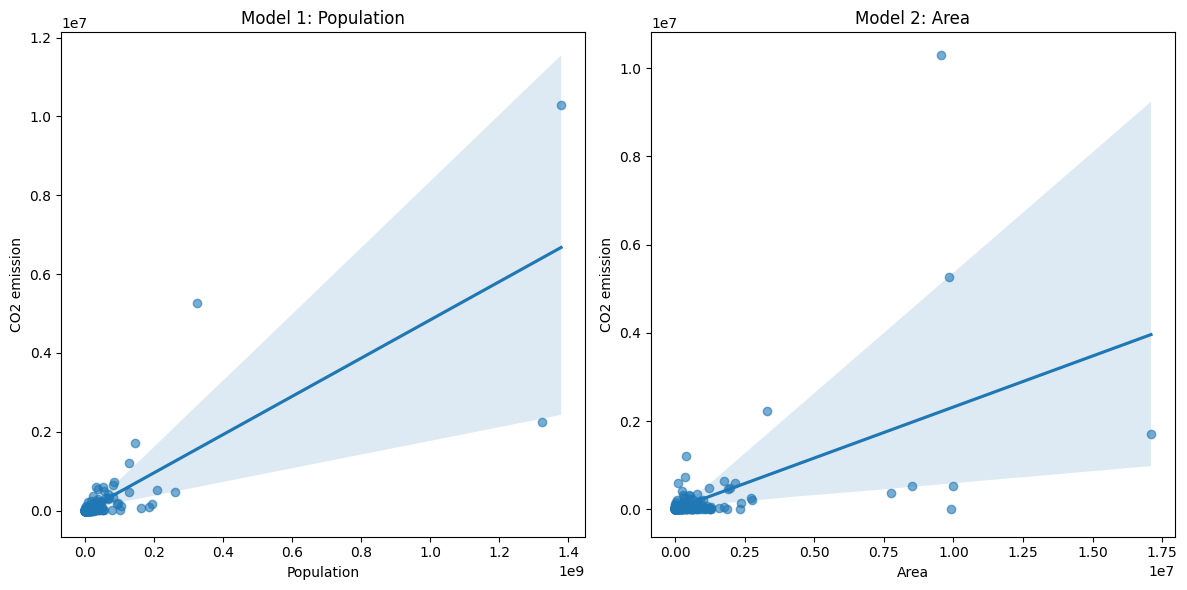

In [14]:
%matplotlib inline
width = 12
height = 6

fig, axes = plt.subplots(1, 2, figsize=(width, height))
sns.regplot(x='Population', y='CO2 emission', data=df, ax=axes[0], scatter_kws={'alpha': 0.6})
axes[0].set_title('Model 1: Population')
sns.regplot(x='Area', y='CO2 emission', data=df, ax=axes[1], scatter_kws={'alpha': 0.6})
axes[1].set_title('Model 2: Area')
plt.tight_layout()

Для візуалізації дисперсії даних використаю діаграми залишків - по ній зможу прийняти рішення про необхідність ускладнення моделі.


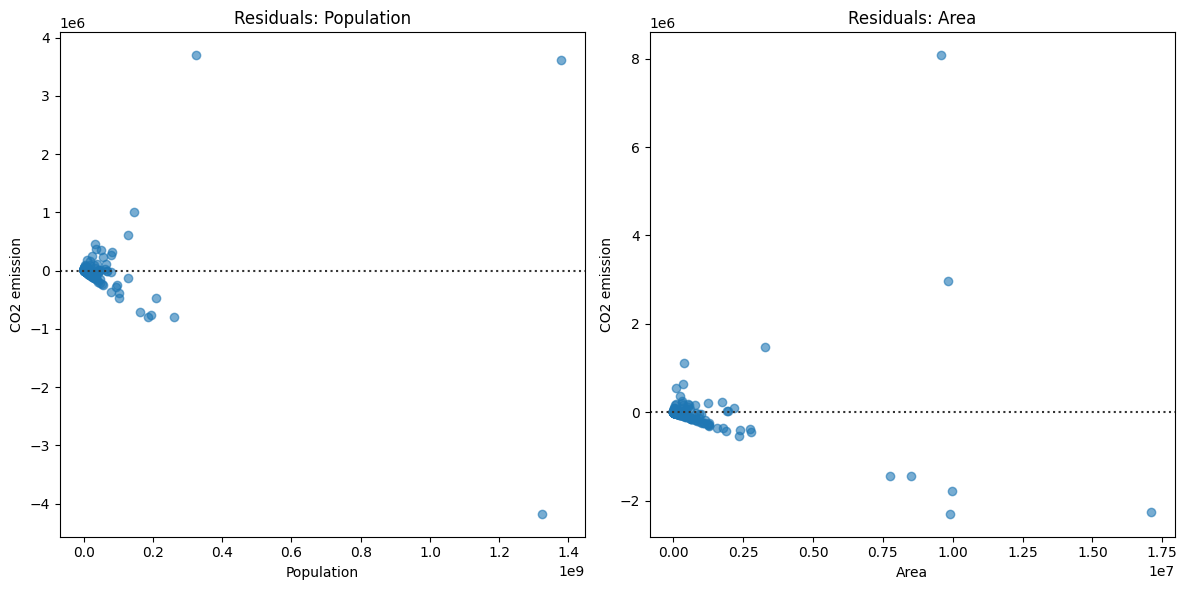

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(width, height))
sns.residplot(x=df['Population'], y=df['CO2 emission'], ax=axes[0], scatter_kws={'alpha': 0.6})
axes[0].set_title('Residuals: Population')
sns.residplot(x=df['Area'], y=df['CO2 emission'], ax=axes[1], scatter_kws={'alpha': 0.6})
axes[1].set_title('Residuals: Area')
plt.tight_layout()

Для візуалізації моделі множинної лінійної регресії використаю діаграму розподілу.


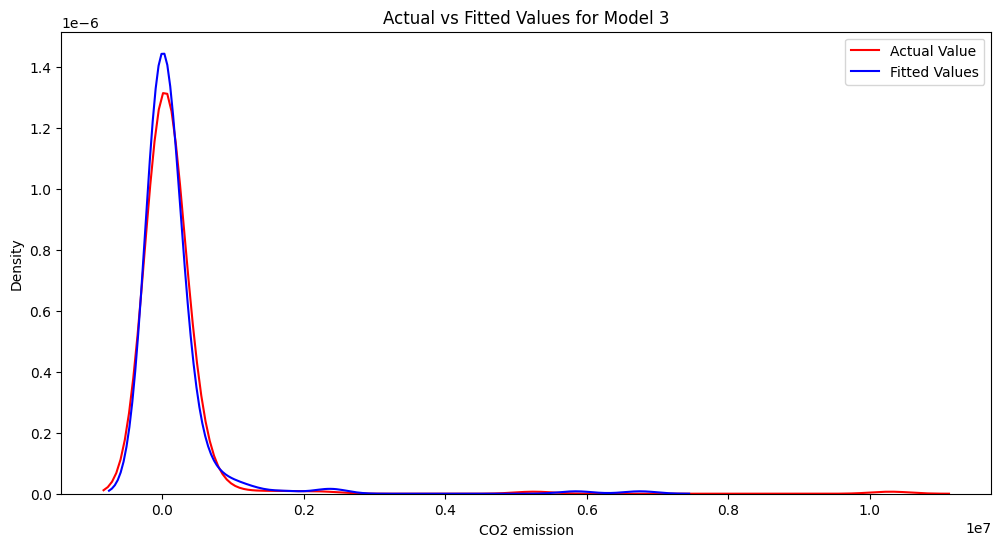

In [16]:
Yhat3 = lm3.predict(X3)
plt.figure(figsize=(width, height))
ax1 = sns.kdeplot(Y, color='r', label='Actual Value')
sns.kdeplot(Yhat3, color='b', label='Fitted Values', ax=ax1)
plt.title('Actual vs Fitted Values for Model 3')
plt.xlabel('CO2 emission')
plt.legend()
plt.show()

Для візуалізації поліноміальних моделей з одним предиктором використаю функцію <code>poly1d</code>. Зручно розміщувати всі моделі на одному графіку для обрання найкращої.


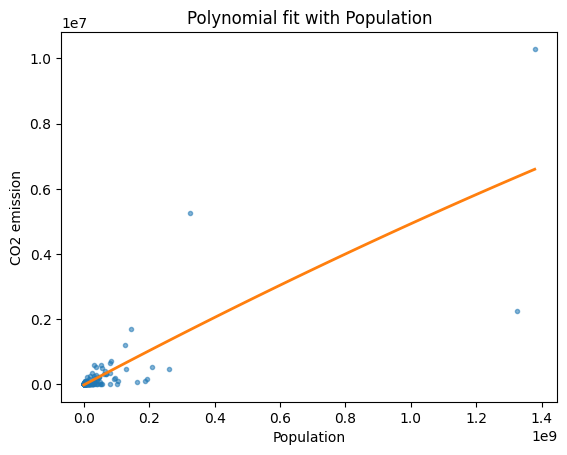

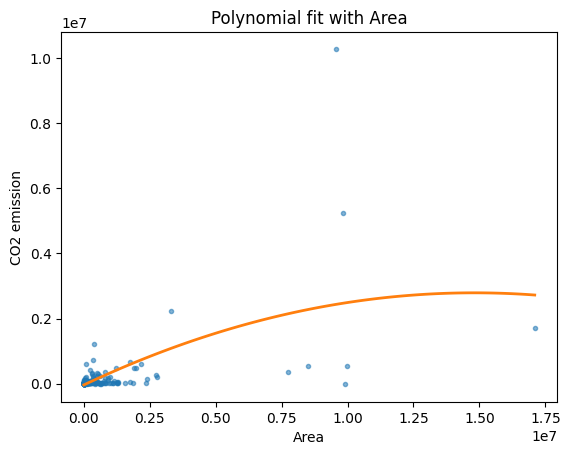

In [17]:
def PlotPolly(model, independent_variable, dependent_variable, name):
    x_new = np.linspace(independent_variable.min(), independent_variable.max(), 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', alpha=0.55)
    plt.plot(x_new, y_new, '-', linewidth=2)
    plt.title('Polynomial fit with ' + name)
    plt.xlabel(name)
    plt.ylabel('CO2 emission')
    plt.show()

PlotPolly(p4, x1, y, 'Population')
PlotPolly(p5, x2, y, 'Area')

Для візуалізації поліноміальних моделей з кількома предикторами використаю діаграму розподілу або діаграму залишків


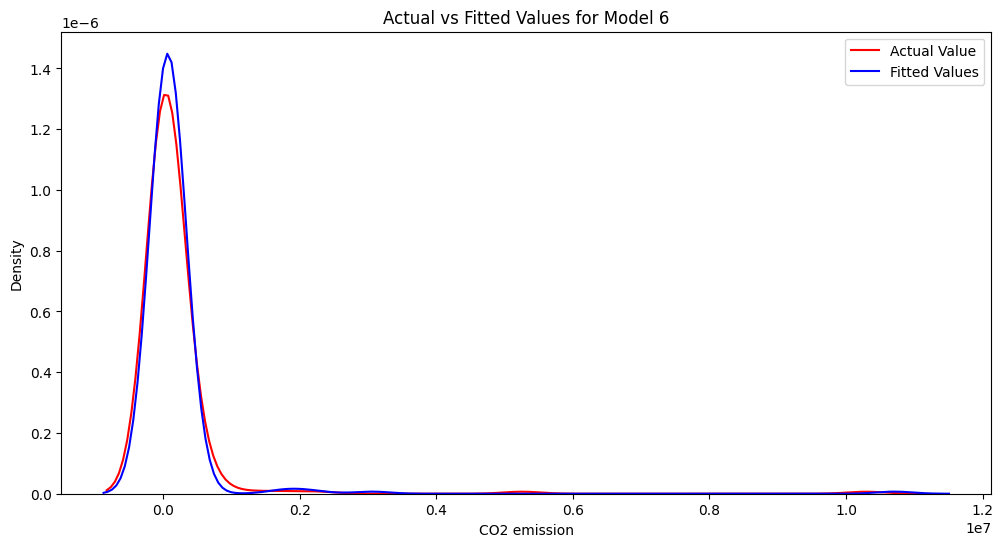

In [18]:
Yhat6 = lm6.predict(X3_poly)
plt.figure(figsize=(width, height))
ax1 = sns.kdeplot(Y, color='r', label='Actual Value')
sns.kdeplot(Yhat6, color='b', label='Fitted Values', ax=ax1)
plt.title('Actual vs Fitted Values for Model 6')
plt.xlabel('CO2 emission')
plt.legend()
plt.show()

<a name="task5"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.</p>
</div>

Значення R^2 отримую безпосередньо з моделі <code>.score(X, Y)</code>, а для розрахунку MSE спочатку формую прогнозовані значення <code>.predict(X)</code> і порівнюю їх з фактичними


Модель 1:
$$
Yhat1 = a + b  X
$$


In [19]:
Yhat1 = lm1.predict(X1)
print('R-square:', lm1.score(X1, Y))
print('MSE:', mean_squared_error(Y, Yhat1))

R-square: 0.6465629960775001
MSE: 231226211453.77188


Модель 2:
$$
Yhat2 = a + b  X
$$

In [20]:
Yhat2 = lm2.predict(X2)
print('R-square:', lm2.score(X2, Y))
print('MSE:', mean_squared_error(Y, Yhat2))

R-square: 0.30436950697780796
MSE: 455096669811.3789


Модель 3:
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [21]:
print('R-square:', lm3.score(X3, Y))
print('MSE:', mean_squared_error(Y, Yhat3))

R-square: 0.7010883020321408
MSE: 195554564783.1422


Модель 4:
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [22]:
# Імпортуємо функцію r2_score з модуля metrics, оскільки використовуємо іншу функцію
from sklearn.metrics import r2_score

Yhat4 = p4(x1)
print('R-square:', r2_score(Y, Yhat4))
print('MSE:', mean_squared_error(Y, Yhat4))

R-square: 0.6470807998651005
MSE: 230887452900.6083


Модель 5:
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [23]:
Yhat5 = p5(x2)
print('R-square:', r2_score(Y, Yhat5))
print('MSE:', mean_squared_error(Y, Yhat5))

R-square: 0.32507007411676425
MSE: 441553906429.6055


Модель 6:
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [ ]:
print('R-square:', r2_score(Y, Yhat6))
print('MSE:', mean_squared_error(Y, Yhat6))

# ---

model_metrics = pd.DataFrame({
    'Model': [
        '1: Linear Population',
        '2: Linear Area',
        '3: Multiple Linear',
        '4: Polynomial Population',
        '5: Polynomial Area',
        '6: Polynomial Population + Area'
    ],
    'R2': [
        lm1.score(X1, Y),
        lm2.score(X2, Y),
        lm3.score(X3, Y),
        r2_score(Y, Yhat4),
        r2_score(Y, Yhat5),
        r2_score(Y, Yhat6)
    ],
    'MSE': [
        mean_squared_error(Y, Yhat1),
        mean_squared_error(Y, Yhat2),
        mean_squared_error(Y, Yhat3),
        mean_squared_error(Y, Yhat4),
        mean_squared_error(Y, Yhat5),
        mean_squared_error(Y, Yhat6)
    ]
})
model_metrics.sort_values('R2', ascending=False)

R-square: 0.9257860529232583
MSE: 48552385939.04709


,Model,R2,MSE
5,6: Polynomial Population + Area,0.925786,4.855239e+10
2,3: Multiple Linear,0.701088,1.955546e+11
3,4: Polynomial Population,0.647081,2.308875e+11
0,1: Linear Population,0.646563,2.312262e+11
4,5: Polynomial Area,0.325070,4.415539e+11
1,2: Linear Area,0.304370,4.550967e+11


<h4>Висновок</h4>
<p>Порівнюючи всі моделі, роблю висновок, що <b>модель 6 — поліноміальна модель другого порядку з ознаками Population та Area — є найкращою моделлю</b> для прогнозування <code>CO2 emission</code> на основі нашого набору даних. Вона має найбільше значення R² та найменше значення MSE серед побудованих моделей.</p>

<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте та оцініть кілька поліноміальних моделей різних порядків.</p>
</div>

1. Побудуйте кілька поліноміальних моделей різних порядків.
2. Побудуйте візуалізації для оцінки всіх моделей, починаючи з лінійної (зручно розміщувати всі моделі на одному графіку для обрання найкращої).
3. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі (теж доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі).
4. Оберіть найкращу модель, висновок обгрунтуйте.


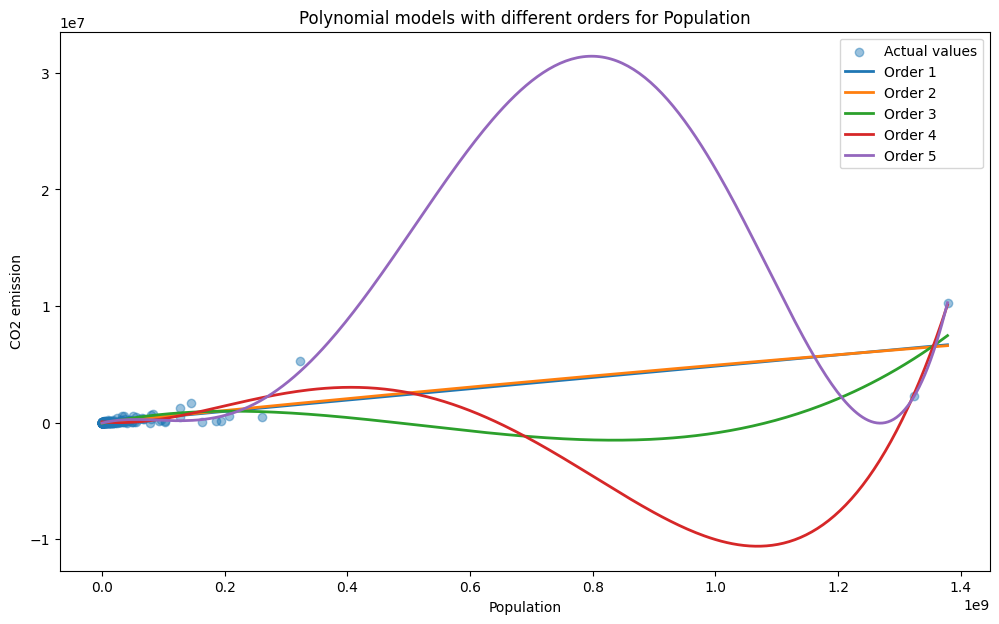

,Order,R2,MSE
4,5,0.935627,4.211450e+10
3,4,0.871125,8.431262e+10
2,3,0.672907,2.139914e+11
1,2,0.647081,2.308875e+11
0,1,0.646563,2.312262e+11


In [25]:
orders = [1, 2, 3, 4, 5]
x = df['Population']
y = Y
x_grid = np.linspace(x.min(), x.max(), 300)

extra_metrics = []
plt.figure(figsize=(12, 7))
plt.scatter(x, y, alpha=0.45, label='Actual values')

for order in orders:
    coefficients = np.polyfit(x, y, order)
    polynomial = np.poly1d(coefficients)
    y_hat = polynomial(x)
    extra_metrics.append({
        'Order': order,
        'R2': r2_score(y, y_hat),
        'MSE': mean_squared_error(y, y_hat)
    })
    plt.plot(x_grid, polynomial(x_grid), linewidth=2, label=f'Order {order}')

plt.xlabel('Population')
plt.ylabel('CO2 emission')
plt.title('Polynomial models with different orders for Population')
plt.legend()
plt.show()

pd.DataFrame(extra_metrics).sort_values('R2', ascending=False)

<h2>Виконав студент групи ІП-45<br>
Янов Богдан</h2>